# Customer Intelligence Platform for Fintech — Exploratory Data Analysis

**Team:** FinSight Colombia &nbsp;|&nbsp; IT3388, Project Group 2
**Dataset:** COFINFAD — anonymized Colombian fintech customer & transaction data (Jan 4 – Dec 29, 2023)

This notebook is the **shared exploration stage** of the big data pipeline described in the project
proposal. Before the four workstreams (inactivity risk, future customer value, satisfaction, and
next-day transaction demand) build any models, we need to understand the two source tables, verify
their quality, and surface the patterns that will drive feature engineering.

**Source tables**
- `customer_data.csv` — one row per customer (48,723 rows, 54 columns): demographics, product
  holdings, engagement, satisfaction/support, and pre-aggregated transaction summaries.
- `transactions_data.csv` — one row per transaction (3,159,157 rows, 4 columns): the raw ledger
  behind every customer-level aggregate.

**Contents**
1. Setup & data loading
2. Dataset overview
3. Data quality audit
4. Customer demographics
5. Product adoption & engagement
6. Customer-level transaction behaviour
7. Satisfaction, support & feedback
8. Customer value & churn signals
9. Transaction-level analysis (the 3.16M-row ledger)
10. Correlation structure
11. Signals for the four workstreams
12. Processing time & a first scalability probe
13. Summary of findings

## 1. Setup & Data Loading

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

DATA_DIR = "."  # place this notebook in the same folder as the two CSVs, or edit this path

# Consistent category orderings used throughout the notebook
INCOME_ORDER = ["Low", "Medium", "High", "Very High"]
EDUCATION_ORDER = ["High School", "Bachelor", "Master", "PhD"]
CLV_ORDER = ["Bronze", "Silver", "Gold", "Platinum"]
SEGMENT_ORDER = ["inactive", "occasional", "regular", "power"]

# Running log of step timings -- feeds the scalability discussion in Section 12
processing_log = []

def log_step(name, t0):
    processing_log.append({"step": name, "seconds": round(time.time() - t0, 3)})

def fmt_thousands(x, pos):
    return f"{x:,.0f}"

In [2]:
t0 = time.time()
cust = pd.read_csv(f"{DATA_DIR}/customer_data.csv")
log_step("load customer_data.csv", t0)

t0 = time.time()
tx = pd.read_csv(f"{DATA_DIR}/transactions_data.csv", parse_dates=["date"])
log_step("load transactions_data.csv", t0)

print(f"customer_data.csv:     {cust.shape[0]:,} rows x {cust.shape[1]} columns")
print(f"transactions_data.csv: {tx.shape[0]:,} rows x {tx.shape[1]} columns")
print()
for row in processing_log:
    print(f"  {row['step']:<32s} {row['seconds']:>6.2f} s")

customer_data.csv:     48,723 rows x 54 columns
transactions_data.csv: 3,159,157 rows x 4 columns

  load customer_data.csv             0.68 s
  load transactions_data.csv         3.88 s


## 2. Dataset Overview

Both files load cleanly as flat tables. `customer_data.csv` is wide (54 columns covering five
thematic groups: demographics, product holdings, engagement, satisfaction/support, and
transaction summaries); `transactions_data.csv` is narrow but long — a plain event ledger of
`customer_id`, `date`, `amount`, `type`.

In [3]:
cust.head()

,customer_id,age,gender,location,income_bracket,occupation,education_level,marital_status,household_size,acquisition_channel,customer_segment,savings_account,credit_card,personal_loan,investment_account,insurance_product,active_products,app_logins_frequency,feature_usage_diversity,bill_payment_user,auto_savings_enabled,credit_utilization_ratio,international_transactions,failed_transactions,tx_count,avg_tx_value,total_tx_volume,first_tx,last_tx,base_satisfaction,tx_satisfaction,product_satisfaction,satisfaction_score,nps_score,last_survey_date,support_tickets_count,resolved_tickets_ratio,app_store_rating,feedback_sentiment,feature_requests,complaint_topics,clv_segment,monthly_transaction_count,average_transaction_value,total_transaction_volume,transaction_frequency,last_transaction_date,preferred_transaction_type,first_transaction_date,weekend_transaction_ratio,avg_daily_transactions,customer_tenure,churn_probability,customer_lifetime_value
0,93716481,44,Male,"Pereira, Risaralda",Very High,Engineer,Master,Married,5,Partnership,occasional,True,True,False,False,True,1,15,3,False,False,0.178710,1,0,76,1.679872e+06,127670300,2023-01-05,2023-12-25,9.213372,0.380,0.6,5,-7,2023-12-16,1,0.0,3.5,Neutral,Budgeting tools,NaN,Gold,1.428571,6.054025e+06,60540250,0.030769,2023-12-05,Transfer,2023-01-05,0.300000,0.030769,11.633333,0.362269,3.124148e+08
1,49020929,44,Male,"Cali, Valle del Cauca",Medium,Construction Worker,Bachelor,Married,2,Paid Ad,regular,True,False,False,False,False,5,30,0,True,False,NaN,1,0,10,5.445810e+06,54458100,2023-02-05,2023-12-20,6.073093,0.050,0.2,3,-46,2023-05-05,1,1.0,4.0,Positive,NaN,NaN,Bronze,1.571429,2.127414e+06,23401550,0.032934,2023-12-18,Transfer,2023-02-05,0.181818,0.032934,11.500000,0.181790,1.670223e+08
2,52690950,45,Male,"Barranquilla, Atlántico",High,Construction Worker,Bachelor,Married,4,Paid Ad,inactive,True,False,False,True,True,3,4,4,True,False,NaN,1,0,10,6.403350e+05,6403350,2023-01-31,2023-12-12,8.198643,0.050,0.6,4,-29,2023-11-16,0,0.0,5.0,Positive,NaN,NaN,Gold,2.500000,3.575915e+06,35759150,0.050000,2023-10-27,Transfer,2023-01-31,0.300000,0.050000,8.766667,0.321265,1.940371e+07
3,23199751,45,Male,"Bogotá, Cundinamarca",High,Electrician,High School,Single,2,Referral,inactive,True,False,False,True,False,2,15,4,True,False,NaN,1,1,23,6.601804e+05,15184150,2023-01-10,2023-12-24,7.529577,0.115,0.4,4,-31,2023-05-07,2,0.5,4.5,Positive,"Cryptocurrency trading, Budgeting tools",NaN,Bronze,1.555556,1.513354e+06,21186950,0.047782,2023-11-30,Transfer,2023-01-10,0.142857,0.047782,10.733333,0.336629,3.597811e+07
4,61997066,44,Female,"Bogotá, Cundinamarca",Medium,Cleaner,Bachelor,Married,3,Paid Ad,power,True,True,False,False,False,1,19,1,False,False,0.403606,0,0,18,1.457447e+07,262340450,2023-01-05,2023-11-27,6.605627,0.090,0.4,3,-47,2023-09-15,2,1.0,4.0,Positive,International transfers,App performance,Gold,2.111111,6.126737e+05,11640800,0.061889,2023-11-17,Payment,2023-01-05,0.315789,0.061889,11.633333,0.398151,3.046620e+08


In [4]:
cust.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 48723 entries, 0 to 48722
Data columns (total 54 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 48723 non-null  int64  
 1   age                         48723 non-null  int64  
 2   gender                      48723 non-null  str    
 3   location                    48723 non-null  str    
 4   income_bracket              48723 non-null  str    
 5   occupation                  48723 non-null  str    
 6   education_level             48723 non-null  str    
 7   marital_status              48723 non-null  str    
 8   household_size              48723 non-null  int64  
 9   acquisition_channel         48723 non-null  str    
 10  customer_segment            48723 non-null  str    
 11  savings_account             48723 non-null  bool   
 12  credit_card                 48723 non-null  bool   
 13  personal_loan               48723 non-null

In [5]:
tx.head()

,customer_id,date,amount,type
0,93716481,2023-11-23,1262800,Transfer
1,93716481,2023-01-05,928900,Withdrawal
2,93716481,2023-11-05,1683100,Payment
3,93716481,2023-04-14,4507350,Payment
4,93716481,2023-08-04,2096150,Payment


In [6]:
tx.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 3159157 entries, 0 to 3159156
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   customer_id  int64         
 1   date         datetime64[us]
 2   amount       int64         
 3   type         str           
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 243.7 MB


In [7]:
cust.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,48723.0,5.502799e+07,2.592111e+07,1.000062e+07,3.270835e+07,5.517447e+07,7.724233e+07,9.999980e+07
age,48723.0,4.454494e+01,1.227684e+01,2.900000e+01,3.000000e+01,4.500000e+01,5.900000e+01,6.000000e+01
household_size,48723.0,3.496234e+00,1.583416e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,1.300000e+01
active_products,48723.0,2.095253e+00,1.178333e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
app_logins_frequency,48723.0,2.237617e+01,1.175071e+01,4.000000e+00,1.500000e+01,2.200000e+01,3.000000e+01,1.000000e+02
feature_usage_diversity,48723.0,2.369538e+00,1.744681e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,1.000000e+01
credit_utilization_ratio,30460.0,2.868762e-01,1.600724e-01,1.794056e-04,1.619276e-01,2.658556e-01,3.909798e-01,9.375464e-01
international_transactions,48723.0,4.939146e-01,7.021834e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+00
failed_transactions,48723.0,1.987562e-01,4.439627e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
tx_count,48723.0,6.483913e+01,6.119342e+02,1.000000e+01,1.200000e+01,1.800000e+01,3.500000e+01,7.746500e+04


## 3. Data Quality Audit

Following the governance checklist in the project proposal (unique customer IDs, referential
integrity, date coverage, duplicate detection, and reconciling every derived feature against the
raw ledger), before trusting any column we check where it actually came from.

### 3.1 Missing values

3 of 54 columns contain missing values; the remaining 51 columns are 100% complete.

complaint_topics            49.97%
credit_utilization_ratio    37.48%
feature_requests            33.07%
dtype: str


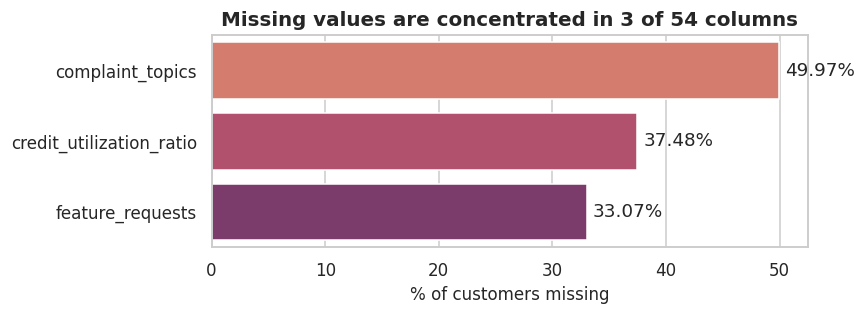

In [8]:
missing = cust.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(cust) * 100).round(2)

print(f"{len(missing)} of {cust.shape[1]} columns contain missing values; the remaining "
      f"{cust.shape[1]-len(missing)} columns are 100% complete.")
print()
print(missing_pct.astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index,
            palette="flare", legend=False, ax=ax)
ax.set_xlabel("% of customers missing")
ax.set_ylabel("")
ax.set_title("Missing values are concentrated in 3 of 54 columns")
for i, v in enumerate(missing_pct.values):
    ax.text(v + 0.5, i, f"{v}%", va="center")
plt.tight_layout()

In [9]:
# Is the missingness random, or structural? Check credit_utilization_ratio against credit_card ownership.
miss_by_card = cust.groupby("credit_card")["credit_utilization_ratio"].apply(lambda s: s.isna().mean() * 100)
print("credit_utilization_ratio: % missing by credit_card ownership")
print(miss_by_card.round(1).astype(str) + "%")
print()
print("-> Missing exactly when the customer has no credit card. This is 'not applicable', not a")
print("   data-collection gap, so it should be imputed with a sentinel / flag rather than a mean.")
print()
print(f"complaint_topics is missing for {cust['complaint_topics'].isna().mean()*100:.1f}% of customers")
print("-> Consistent with 'no complaint filed' rather than missing data (confirmed in Section 7).")
print()
print(f"feature_requests is missing for {cust['feature_requests'].isna().mean()*100:.1f}% of customers")
print("-> Consistent with 'no feature request submitted'.")

credit_utilization_ratio: % missing by credit_card ownership
credit_card
False    100.0%
True       0.0%
Name: credit_utilization_ratio, dtype: str

-> Missing exactly when the customer has no credit card. This is 'not applicable', not a
   data-collection gap, so it should be imputed with a sentinel / flag rather than a mean.

complaint_topics is missing for 50.0% of customers
-> Consistent with 'no complaint filed' rather than missing data (confirmed in Section 7).

feature_requests is missing for 33.1% of customers
-> Consistent with 'no feature request submitted'.


### 3.2 Uniqueness, duplicates & referential integrity

In [10]:
t0 = time.time()
dup_customer_ids = cust["customer_id"].duplicated().sum()
dup_tx_rows = tx.duplicated().sum()
cust_ids, tx_ids = set(cust["customer_id"]), set(tx["customer_id"])
customers_without_tx = cust_ids - tx_ids
tx_ids_without_customer = tx_ids - cust_ids
log_step("uniqueness + referential integrity check", t0)

print(f"Duplicate customer_id values in customer_data:      {dup_customer_ids}")
print(f"Fully duplicated rows in transactions_data:          {dup_tx_rows} "
      f"of {len(tx):,} ({dup_tx_rows/len(tx)*100:.4f}%)")
print(f"Customers with zero transactions:                    {len(customers_without_tx)}")
print(f"Transaction customer_ids missing from customer table: {len(tx_ids_without_customer)}")
print()
print("-> customer_id is a clean primary key, and the join between the two tables is complete")
print("   and lossless in both directions. The 102 duplicate rows are a rounding error at this")
print("   scale (0.003%) but worth a quick manual look before modeling -- shown below.")
print()
tx[tx.duplicated(keep=False)].sort_values(["customer_id", "date"]).head(6)

Duplicate customer_id values in customer_data:      0
Fully duplicated rows in transactions_data:          102 of 3,159,157 (0.0032%)
Customers with zero transactions:                    0
Transaction customer_ids missing from customer table: 0

-> customer_id is a clean primary key, and the join between the two tables is complete
   and lossless in both directions. The 102 duplicate rows are a rounding error at this
   scale (0.003%) but worth a quick manual look before modeling -- shown below.



,customer_id,date,amount,type
2425691,10189624,2023-06-02,1812200,Transfer
2429382,10189624,2023-06-02,1812200,Transfer
2025755,10435643,2023-01-10,457500,Payment
2034625,10435643,2023-01-10,457500,Payment
2025386,10435643,2023-01-18,331150,Transfer
2034188,10435643,2023-01-18,371850,Transfer


### 3.3 Date coverage

In [11]:
t0 = time.time()
expected_days = pd.date_range(tx["date"].min(), tx["date"].max(), freq="D")
present_days = set(tx["date"].dt.normalize().unique())
missing_days = [d for d in expected_days if d not in present_days]
log_step("date coverage check", t0)

print(f"Transaction date range: {tx['date'].min().date()} to {tx['date'].max().date()} "
      f"({len(expected_days)} calendar days)")
print(f"Days with at least one transaction: {len(present_days)}")
print(f"Missing calendar days: {len(missing_days)}")
print()
print("-> Every single day in the ~year of coverage has activity; there are no ingestion gaps to")
print("   patch before building the daily demand-classification target.")

Transaction date range: 2023-01-04 to 2023-12-29 (360 calendar days)
Days with at least one transaction: 360
Missing calendar days: 0

-> Every single day in the ~year of coverage has activity; there are no ingestion gaps to
   patch before building the daily demand-classification target.


### 3.4 Reconciling the two "transaction summary" feature sets

`customer_data.csv` contains two groups of columns that describe the same thing under different
names: `{tx_count, avg_tx_value, total_tx_volume, first_tx, last_tx}` and
`{monthly_transaction_count, average_transaction_value, total_transaction_volume,
transaction_frequency, first_transaction_date, last_transaction_date, weekend_transaction_ratio,
avg_daily_transactions}`. Rather than assume they agree, we recompute the ground truth directly
from the transaction ledger and check both sets against it.

In [12]:
t0 = time.time()
agg = tx.groupby("customer_id").agg(
    recomputed_count=("amount", "size"),
    recomputed_sum=("amount", "sum"),
    recomputed_first=("date", "min"),
    recomputed_last=("date", "max"),
).reset_index()
log_step("groupby customer_id over 3.16M rows", t0)

check = cust[[
    "customer_id", "tx_count", "total_tx_volume", "first_tx", "last_tx",
    "avg_tx_value", "average_transaction_value",
    "total_transaction_volume", "last_transaction_date",
]].merge(agg, on="customer_id")

check["first_tx"] = pd.to_datetime(check["first_tx"])
check["last_tx"] = pd.to_datetime(check["last_tx"])
check["last_transaction_date"] = pd.to_datetime(check["last_transaction_date"])

print("SET A  tx_count / avg_tx_value / total_tx_volume / first_tx / last_tx  -- vs. the raw ledger:")
print(f"  tx_count matches recomputed count:      {(check['tx_count']==check['recomputed_count']).mean()*100:5.1f}% of customers")
print(f"  total_tx_volume matches recomputed sum: {(check['total_tx_volume']==check['recomputed_sum']).mean()*100:5.1f}% of customers")
print(f"  first_tx matches recomputed min date:   {(check['first_tx']==check['recomputed_first']).mean()*100:5.1f}% of customers")
print(f"  last_tx matches recomputed max date:    {(check['last_tx']==check['recomputed_last']).mean()*100:5.1f}% of customers")
print()
print("SET B  average_transaction_value / total_transaction_volume / last_transaction_date  -- vs. the same ledger:")
print(f"  correlation(avg_tx_value, average_transaction_value):   {cust['avg_tx_value'].corr(cust['average_transaction_value']):6.4f}")
print(f"  correlation(total_tx_volume, total_transaction_volume): {cust['total_tx_volume'].corr(cust['total_transaction_volume']):6.4f}")
print(f"  last_transaction_date matches ledger max date:          {(check['last_tx']==check['last_transaction_date']).mean()*100:5.1f}% of customers")
print()
print("-> Set A is fully verified against the raw ledger (100% match on every check) and should be")
print("   treated as authoritative. Set B is essentially uncorrelated with the ledger it claims to")
print("   summarize -- it looks like an independently generated / stale feature set. Recommendation")
print("   for all four workstreams: build features from Set A and the raw ledger, and exclude or")
print("   re-derive Set B rather than trust it at face value. transaction_frequency and")
print("   avg_daily_transactions are exact duplicates of each other (kept as one is redundant).")

SET A  tx_count / avg_tx_value / total_tx_volume / first_tx / last_tx  -- vs. the raw ledger:
  tx_count matches recomputed count:      100.0% of customers
  total_tx_volume matches recomputed sum: 100.0% of customers
  first_tx matches recomputed min date:   100.0% of customers
  last_tx matches recomputed max date:    100.0% of customers

SET B  average_transaction_value / total_transaction_volume / last_transaction_date  -- vs. the same ledger:
  correlation(avg_tx_value, average_transaction_value):   0.0020
  correlation(total_tx_volume, total_transaction_volume): -0.0006
  last_transaction_date matches ledger max date:            3.6% of customers

-> Set A is fully verified against the raw ledger (100% match on every check) and should be
   treated as authoritative. Set B is essentially uncorrelated with the ledger it claims to
   summarize -- it looks like an independently generated / stale feature set. Recommendation
   for all four workstreams: build features from Set A and th

## 4. Customer Demographics

All 48,723 customers pass the quality checks above, so the demographic picture below can be
read at face value.

Age: 29-60 years, mean 44.5, median 45
Household size: 1-13 people, mean 3.5


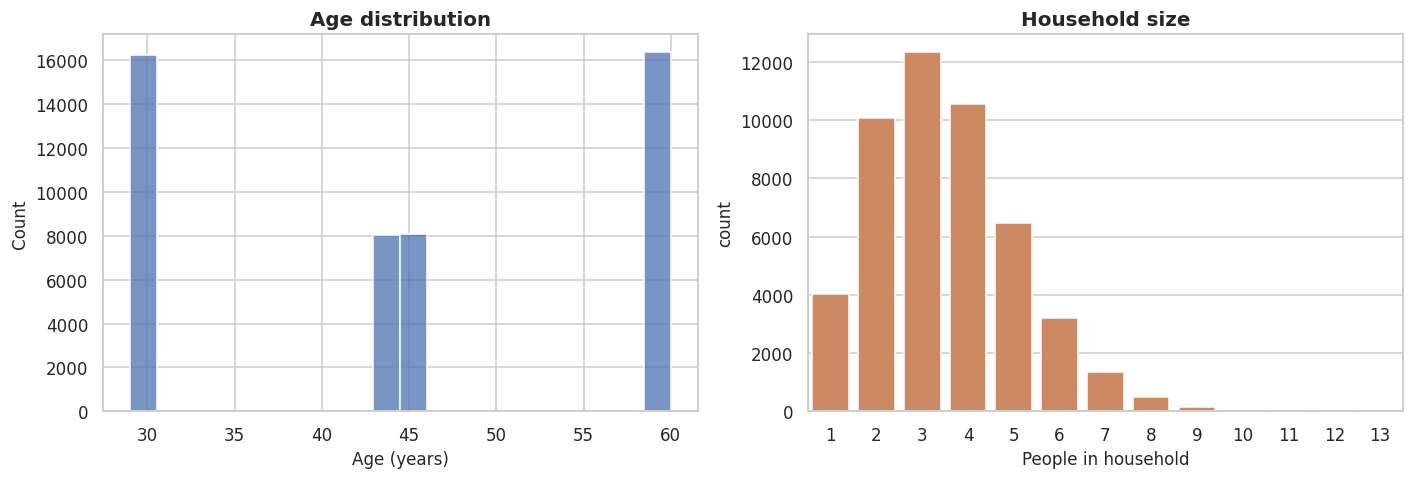

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(cust["age"], bins=20, color=sns.color_palette("deep")[0], ax=axes[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age (years)")

sns.countplot(x="household_size", data=cust, color=sns.color_palette("deep")[1], ax=axes[1])
axes[1].set_title("Household size")
axes[1].set_xlabel("People in household")

plt.tight_layout()
print(f"Age: {cust['age'].min()}-{cust['age'].max()} years, mean {cust['age'].mean():.1f}, "
      f"median {cust['age'].median():.0f}")
print(f"Household size: {cust['household_size'].min()}-{cust['household_size'].max()} people, "
      f"mean {cust['household_size'].mean():.1f}")

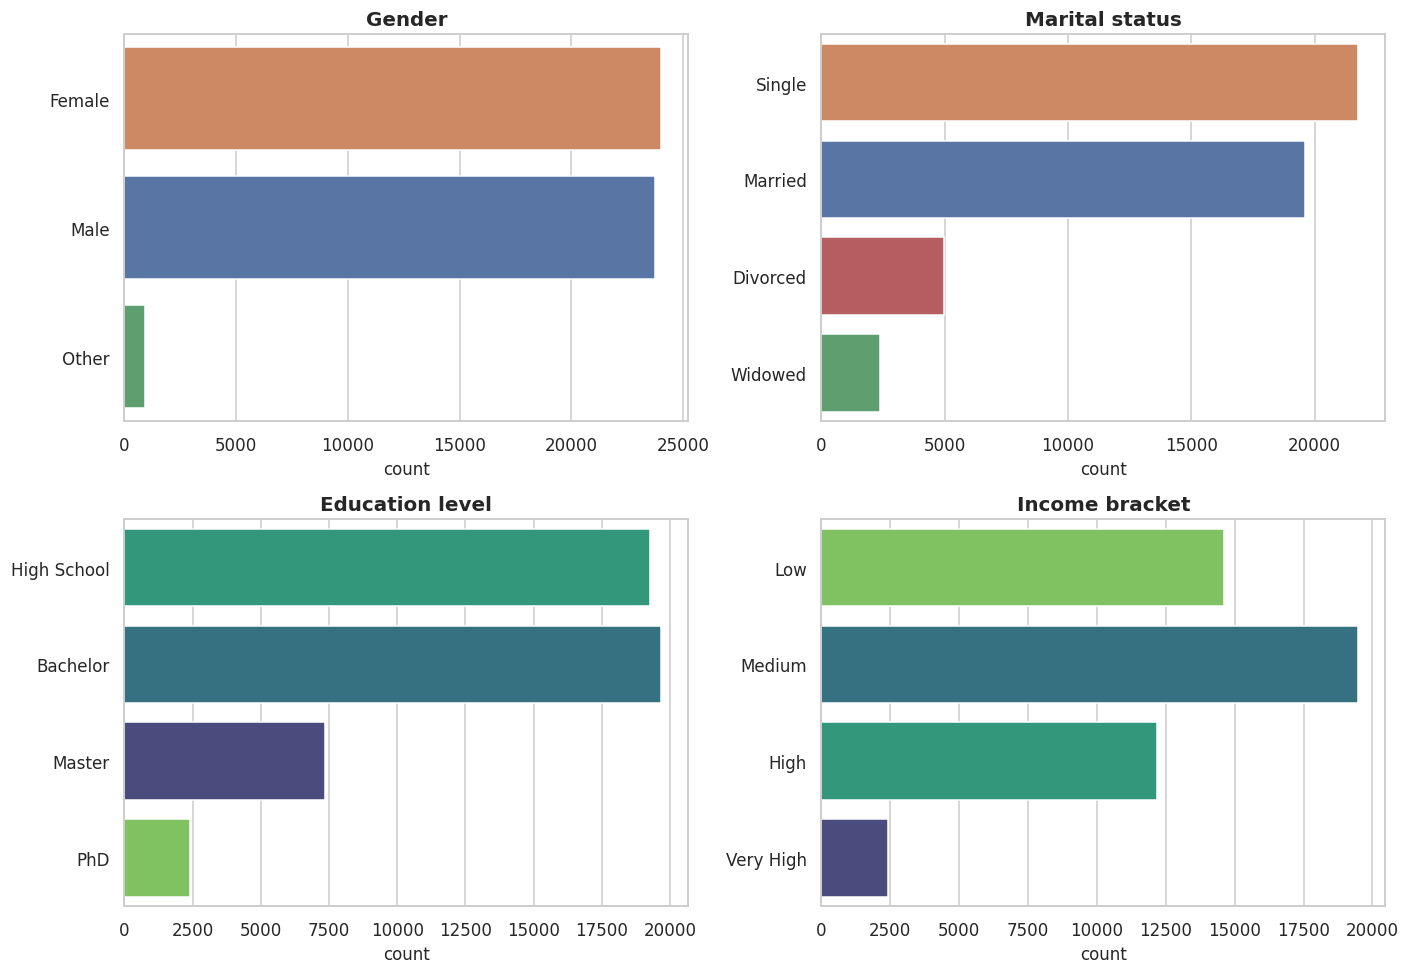

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(y="gender", data=cust, order=cust["gender"].value_counts().index,
              hue="gender", palette="deep", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_ylabel("")

sns.countplot(y="marital_status", data=cust, order=cust["marital_status"].value_counts().index,
              hue="marital_status", palette="deep", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Marital status")
axes[0, 1].set_ylabel("")

sns.countplot(y="education_level", data=cust, order=EDUCATION_ORDER,
              hue="education_level", palette="viridis", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Education level")
axes[1, 0].set_ylabel("")

sns.countplot(y="income_bracket", data=cust, order=INCOME_ORDER,
              hue="income_bracket", palette="viridis", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Income bracket")
axes[1, 1].set_ylabel("")

plt.tight_layout()

Bogotá alone accounts for 34.8% of customers; the 35 occupation categories are close to evenly sized (1329-1456 each), suggesting occupation was assigned close to uniformly at random in this dataset.


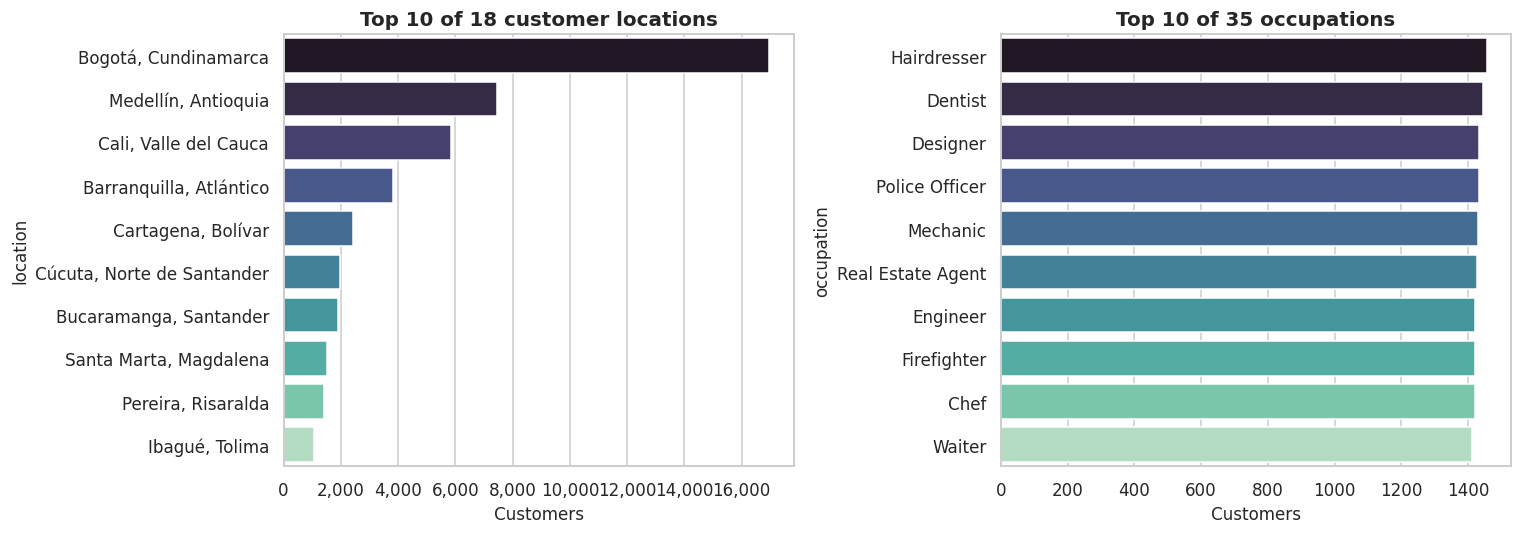

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_loc = cust["location"].value_counts().head(10)
sns.barplot(x=top_loc.values, y=top_loc.index, hue=top_loc.index, palette="mako",
            legend=False, ax=axes[0])
axes[0].set_title(f"Top 10 of {cust['location'].nunique()} customer locations")
axes[0].set_xlabel("Customers")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))

top_occ = cust["occupation"].value_counts().head(10)
sns.barplot(x=top_occ.values, y=top_occ.index, hue=top_occ.index, palette="mako",
            legend=False, ax=axes[1])
axes[1].set_title(f"Top 10 of {cust['occupation'].nunique()} occupations")
axes[1].set_xlabel("Customers")

plt.tight_layout()
print(f"Bogotá alone accounts for {cust['location'].value_counts(normalize=True).iloc[0]*100:.1f}% "
      f"of customers; the 35 occupation categories are close to evenly sized "
      f"({cust['occupation'].value_counts().min()}-{cust['occupation'].value_counts().max()} each), "
      f"suggesting occupation was assigned close to uniformly at random in this dataset.")

## 5. Product Adoption & Engagement

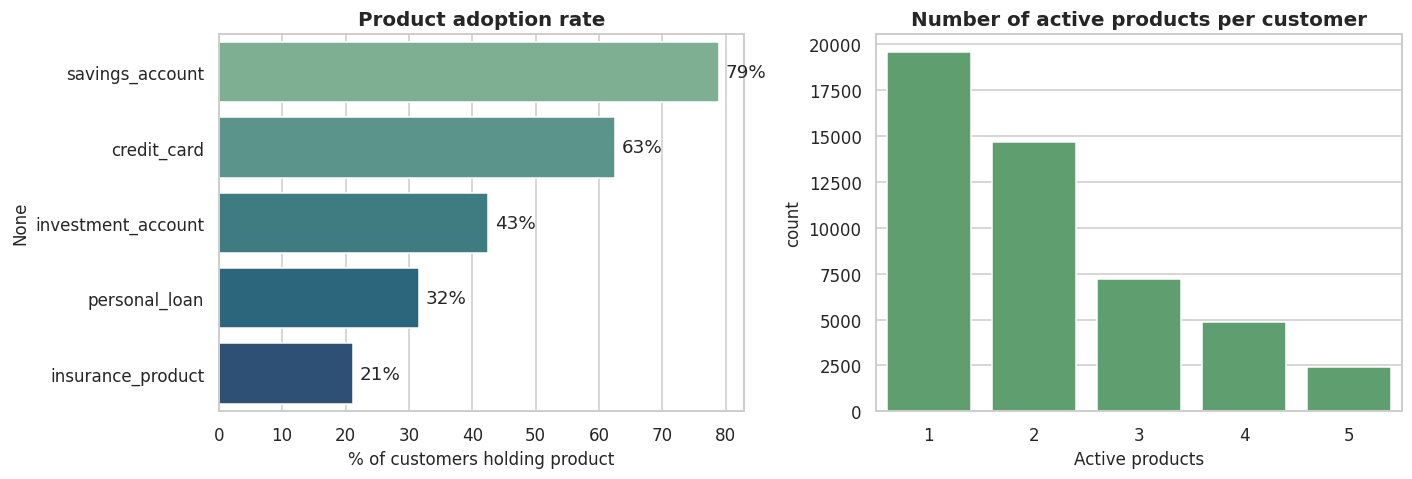

In [16]:
product_cols = ["savings_account", "credit_card", "personal_loan", "investment_account", "insurance_product"]
adoption = cust[product_cols].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(x=adoption.values, y=adoption.index, hue=adoption.index, palette="crest",
            legend=False, ax=axes[0])
axes[0].set_title("Product adoption rate")
axes[0].set_xlabel("% of customers holding product")
for i, v in enumerate(adoption.values):
    axes[0].text(v + 1, i, f"{v:.0f}%", va="center")

sns.countplot(x="active_products", data=cust, color=sns.color_palette("deep")[2], ax=axes[1])
axes[1].set_title("Number of active products per customer")
axes[1].set_xlabel("Active products")

plt.tight_layout()

customer_segment
inactive       9904
occasional    19391
regular       14568
power          4860
Name: count, dtype: int64


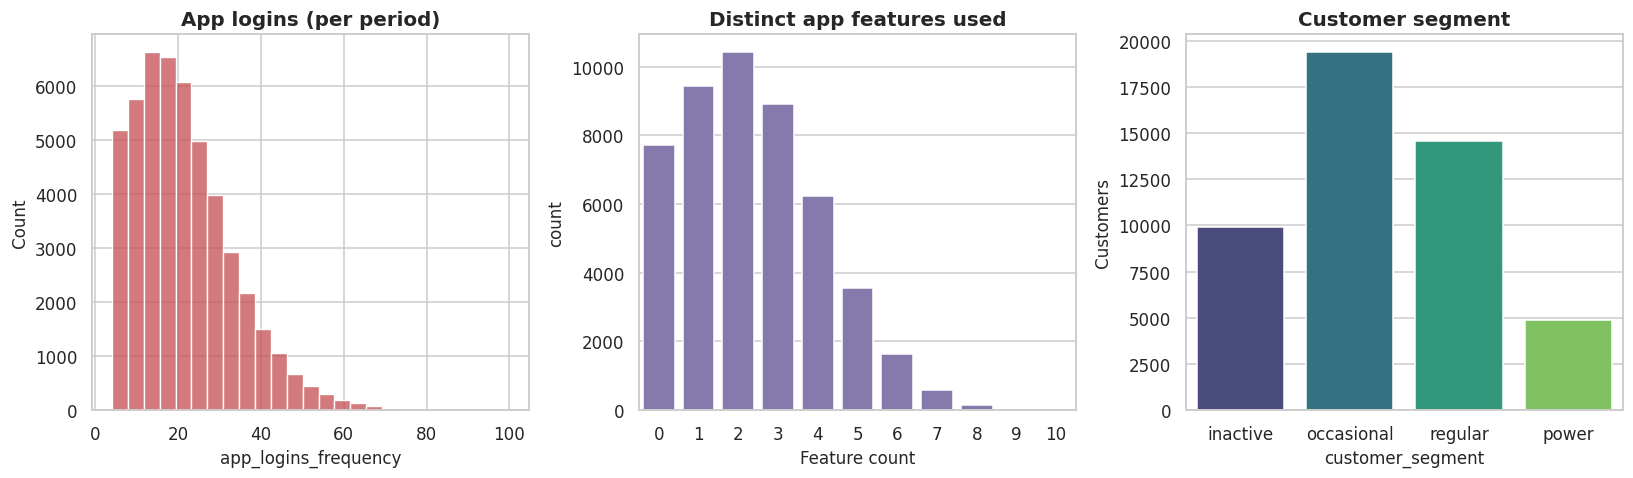

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(cust["app_logins_frequency"], bins=25, color=sns.color_palette("deep")[3], ax=axes[0])
axes[0].set_title("App logins (per period)")

sns.countplot(x="feature_usage_diversity", data=cust, color=sns.color_palette("deep")[4], ax=axes[1])
axes[1].set_title("Distinct app features used")
axes[1].set_xlabel("Feature count")

seg_counts = cust["customer_segment"].value_counts().reindex(SEGMENT_ORDER)
sns.barplot(x=seg_counts.index, y=seg_counts.values, hue=seg_counts.index, palette="viridis",
            legend=False, ax=axes[2])
axes[2].set_title("Customer segment")
axes[2].set_ylabel("Customers")

plt.tight_layout()
print(cust["customer_segment"].value_counts().reindex(SEGMENT_ORDER))

## 6. Customer-Level Transaction Behaviour

Using the ledger-verified fields (`tx_count`, `avg_tx_value`, `total_tx_volume`, `customer_tenure`)
rather than the unreliable "Set B" columns flagged in Section 3.4.

                   count          mean           std        min           25%           50%           75%           max
tx_count         48723.0  6.483913e+01  6.119342e+02       10.0  1.200000e+01  1.800000e+01  3.500000e+01  7.746500e+04
avg_tx_value     48723.0  3.564852e+06  3.959443e+06   318215.0  1.339114e+06  1.763107e+06  4.658536e+06  5.167030e+07
total_tx_volume  48723.0  2.574728e+08  6.211110e+09  3182150.0  2.015845e+07  4.808115e+07  1.204450e+08  1.073087e+12
customer_tenure  48723.0  1.137391e+01  7.195875e-01        4.7  1.116667e+01  1.163333e+01  1.186667e+01  1.196667e+01


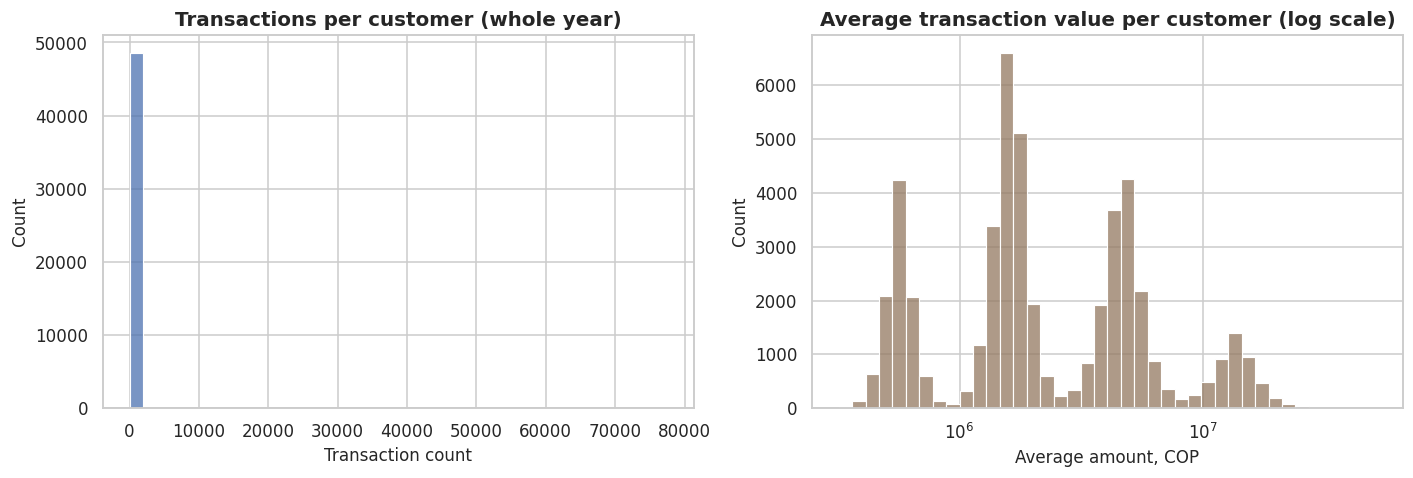

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(cust["tx_count"], bins=40, color=sns.color_palette("deep")[0], ax=axes[0])
axes[0].set_title("Transactions per customer (whole year)")
axes[0].set_xlabel("Transaction count")

sns.histplot(cust, x="avg_tx_value", bins=40, log_scale=True, color=sns.color_palette("deep")[5], ax=axes[1])
axes[1].set_title("Average transaction value per customer (log scale)")
axes[1].set_xlabel("Average amount, COP")

plt.tight_layout()
print(cust[["tx_count", "avg_tx_value", "total_tx_volume", "customer_tenure"]].describe().T)

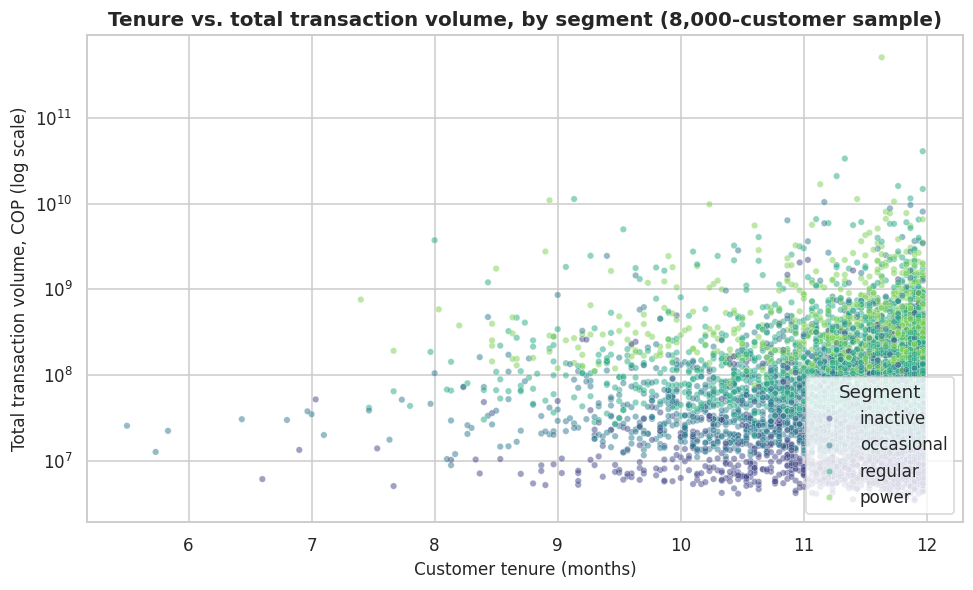

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sample = cust.sample(8000, random_state=42)
sns.scatterplot(data=sample, x="customer_tenure", y="total_tx_volume", hue="customer_segment",
                 hue_order=SEGMENT_ORDER, palette="viridis", alpha=0.5, s=18, ax=ax)
ax.set_yscale("log")
ax.set_title("Tenure vs. total transaction volume, by segment (8,000-customer sample)")
ax.set_xlabel("Customer tenure (months)")
ax.set_ylabel("Total transaction volume, COP (log scale)")
ax.legend(title="Segment", loc="lower right")
plt.tight_layout()

## 7. Satisfaction, Support & Feedback

satisfaction_score observed range: 2-6 (proposal specifies a 1-6 scale)


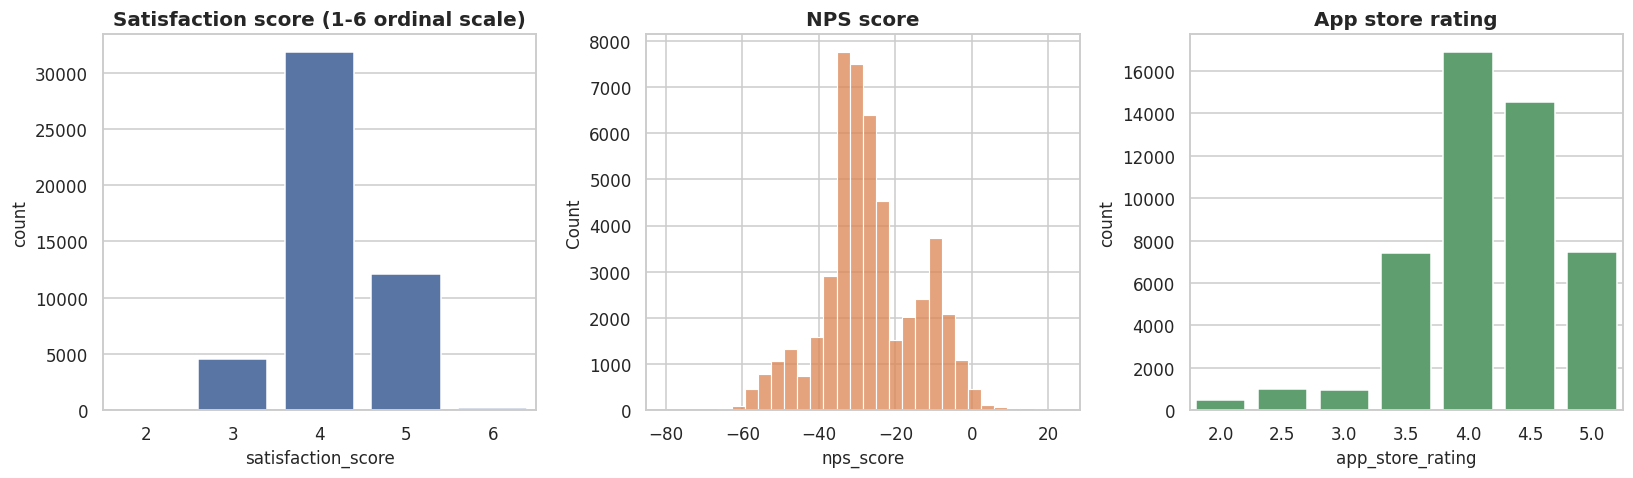

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.countplot(x="satisfaction_score", data=cust, color=sns.color_palette("deep")[0], ax=axes[0])
axes[0].set_title("Satisfaction score (1-6 ordinal scale)")

sns.histplot(cust["nps_score"], bins=30, color=sns.color_palette("deep")[1], ax=axes[1])
axes[1].set_title("NPS score")

sns.countplot(x="app_store_rating", data=cust, color=sns.color_palette("deep")[2], ax=axes[2])
axes[2].set_title("App store rating")

plt.tight_layout()
print(f"satisfaction_score observed range: {cust['satisfaction_score'].min()}-{cust['satisfaction_score'].max()} "
      f"(proposal specifies a 1-6 scale)")

24,377 of 48,723 customers (50.0%) have a recorded complaint; the rest have none on file (not missing data).



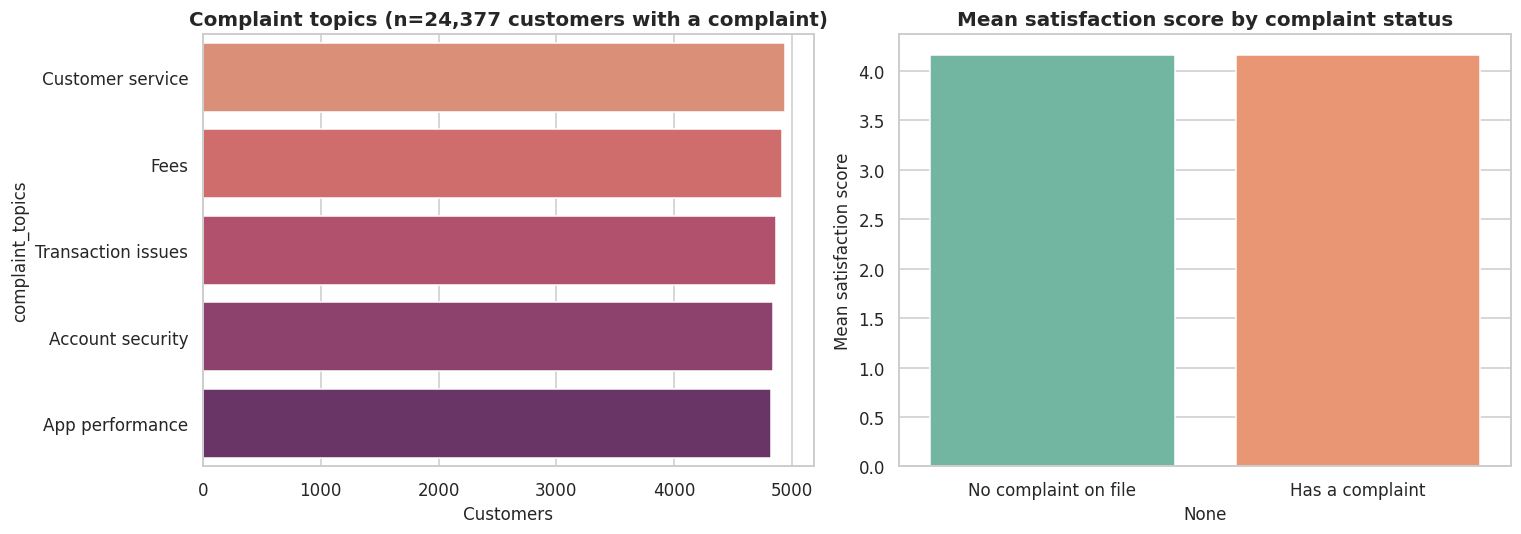

In [21]:
has_complaint = cust["complaint_topics"].notna()
print(f"{has_complaint.sum():,} of {len(cust):,} customers ({has_complaint.mean()*100:.1f}%) "
      f"have a recorded complaint; the rest have none on file (not missing data).")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

topic_counts = cust.loc[has_complaint, "complaint_topics"].value_counts()
sns.barplot(x=topic_counts.values, y=topic_counts.index, hue=topic_counts.index, palette="flare",
            legend=False, ax=axes[0])
axes[0].set_title(f"Complaint topics (n={has_complaint.sum():,} customers with a complaint)")
axes[0].set_xlabel("Customers")

sat_by_complaint = cust.groupby(has_complaint)["satisfaction_score"].mean()
sat_by_complaint.index = ["No complaint on file", "Has a complaint"]
sns.barplot(x=sat_by_complaint.index, y=sat_by_complaint.values,
            hue=sat_by_complaint.index, palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Mean satisfaction score by complaint status")
axes[1].set_ylabel("Mean satisfaction score")

plt.tight_layout()

Support & sentiment summary:
  Mean support tickets per customer: 1.00
  Mean resolved-ticket ratio (customers with >=1 ticket): 0.80

feedback_sentiment
Positive    79.8%
Neutral     17.1%
Negative     3.0%
Name: proportion, dtype: str


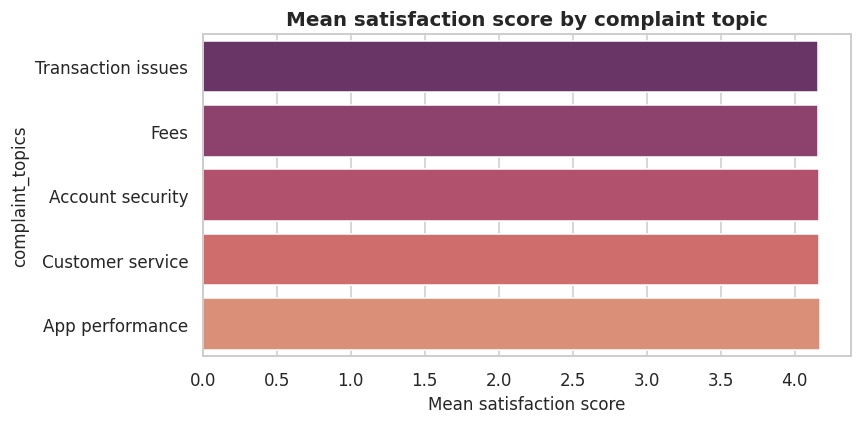

In [22]:
sat_by_topic = (cust.loc[has_complaint]
                 .groupby("complaint_topics")["satisfaction_score"]
                 .mean()
                 .sort_values())

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=sat_by_topic.values, y=sat_by_topic.index, hue=sat_by_topic.index, palette="flare_r",
            legend=False, ax=ax)
ax.set_title("Mean satisfaction score by complaint topic")
ax.set_xlabel("Mean satisfaction score")
plt.tight_layout()

print("Support & sentiment summary:")
print(f"  Mean support tickets per customer: {cust['support_tickets_count'].mean():.2f}")
print(f"  Mean resolved-ticket ratio (customers with >=1 ticket): "
      f"{cust.loc[cust['support_tickets_count']>0, 'resolved_tickets_ratio'].mean():.2f}")
print()
print(cust["feedback_sentiment"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

## 8. Customer Value & Churn Signals

customer_lifetime_value: min 0, median 129,681,954, max 17,768,601,886 COP (1 customers at exactly 0)


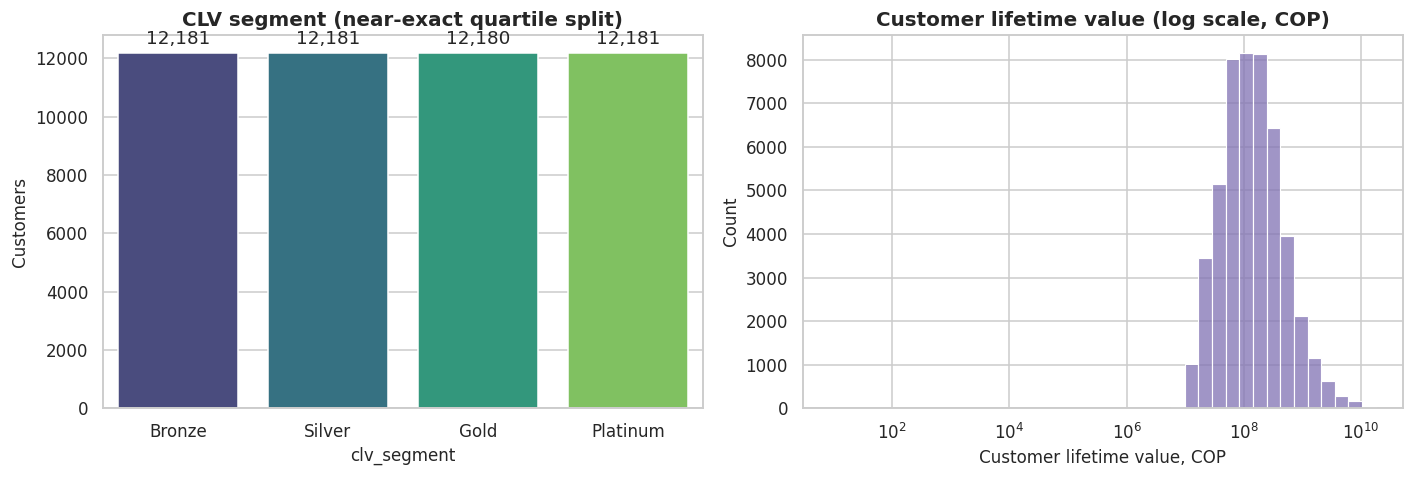

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

clv_counts = cust["clv_segment"].value_counts().reindex(CLV_ORDER)
sns.barplot(x=clv_counts.index, y=clv_counts.values, hue=clv_counts.index, palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("CLV segment (near-exact quartile split)")
axes[0].set_ylabel("Customers")
for i, v in enumerate(clv_counts.values):
    axes[0].text(i, v + 300, f"{v:,}", ha="center")

sns.histplot(cust[cust["customer_lifetime_value"] > 0], x="customer_lifetime_value",
             bins=40, log_scale=True, color=sns.color_palette("deep")[4], ax=axes[1])
axes[1].set_title("Customer lifetime value (log scale, COP)")
axes[1].set_xlabel("Customer lifetime value, COP")

plt.tight_layout()
print(f"customer_lifetime_value: min {cust['customer_lifetime_value'].min():,.0f}, "
      f"median {cust['customer_lifetime_value'].median():,.0f}, "
      f"max {cust['customer_lifetime_value'].max():,.0f} COP "
      f"({(cust['customer_lifetime_value']==0).sum()} customers at exactly 0)")

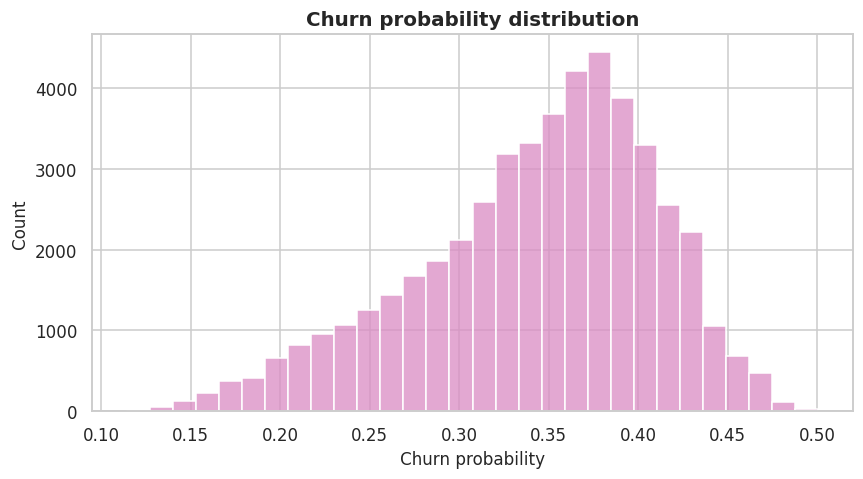

customer_segment,inactive,occasional,regular,power
clv_segment,,,,
Bronze,51.9,44.2,3.9,0.0
Silver,16.9,55.4,26.8,0.9
Gold,8.2,36.9,45.3,9.5
Platinum,4.3,22.7,43.5,29.4


In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(cust["churn_probability"], bins=30, color=sns.color_palette("deep")[6], ax=ax)
ax.set_title("Churn probability distribution")
ax.set_xlabel("Churn probability")
plt.tight_layout()

cross = pd.crosstab(cust["clv_segment"], cust["customer_segment"], normalize="index") \
          .reindex(CLV_ORDER)[SEGMENT_ORDER] * 100
cross.round(1)

## 9. Transaction-Level Analysis (the 3.16M-row ledger)

Everything so far used the customer-level table. This section works directly on the raw
transaction ledger, which is where the demand-classification workstream's daily target will be
built.

Total value across all transactions: 12,544.8 billion COP
amount range: 36,400 - 689,739,900 COP (no zero or negative amounts)


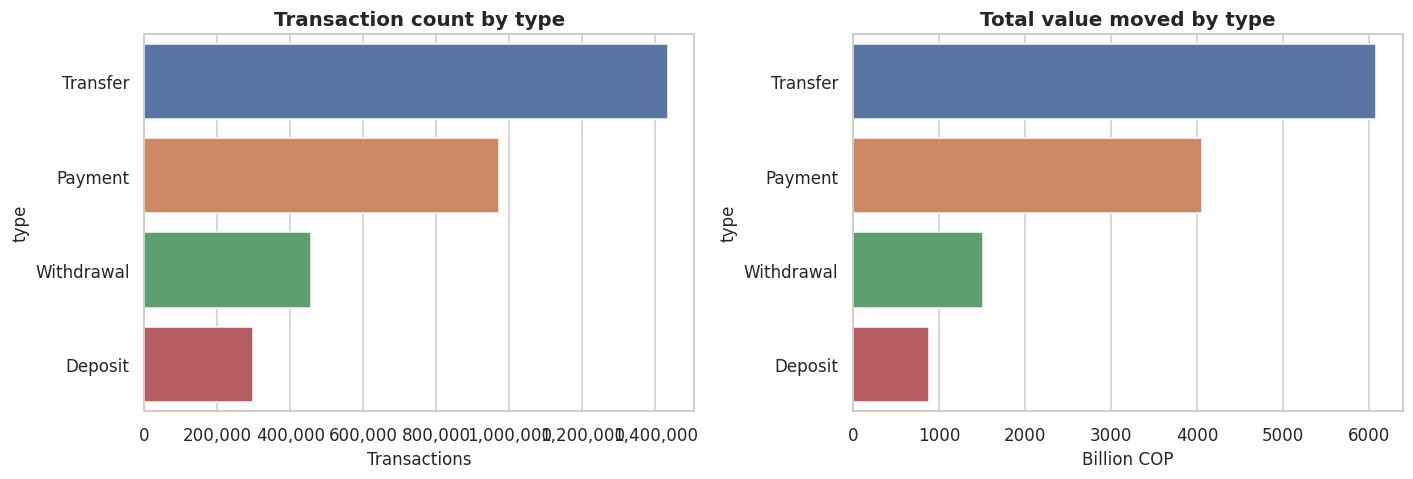

In [25]:
type_counts = tx["type"].value_counts()
type_amount = tx.groupby("type")["amount"].sum().reindex(type_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index, palette="deep",
            legend=False, ax=axes[0])
axes[0].set_title("Transaction count by type")
axes[0].set_xlabel("Transactions")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))

sns.barplot(x=(type_amount / 1e9).values, y=type_amount.index, hue=type_amount.index, palette="deep",
            legend=False, ax=axes[1])
axes[1].set_title("Total value moved by type")
axes[1].set_xlabel("Billion COP")

plt.tight_layout()
print(f"Total value across all transactions: {tx['amount'].sum()/1e9:,.1f} billion COP")
print(f"amount range: {tx['amount'].min():,} - {tx['amount'].max():,} COP "
      f"(no zero or negative amounts)")

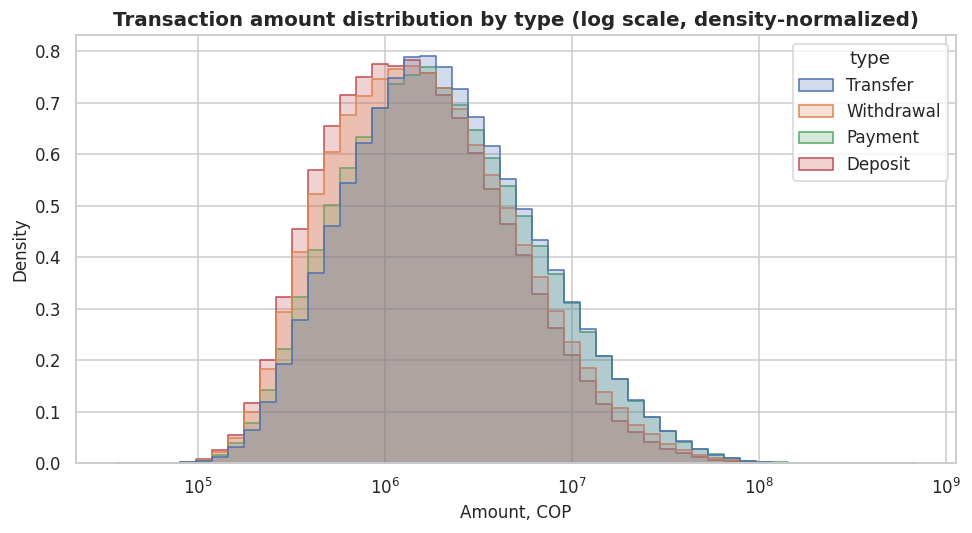

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(tx, x="amount", hue="type", bins=50, log_scale=True, element="step",
             stat="density", common_norm=False, palette="deep", ax=ax)
ax.set_title("Transaction amount distribution by type (log scale, density-normalized)")
ax.set_xlabel("Amount, COP")
plt.tight_layout()

Daily transaction count: mean 8,775, min 8,539, max 9,045
Coefficient of variation: 1.0%


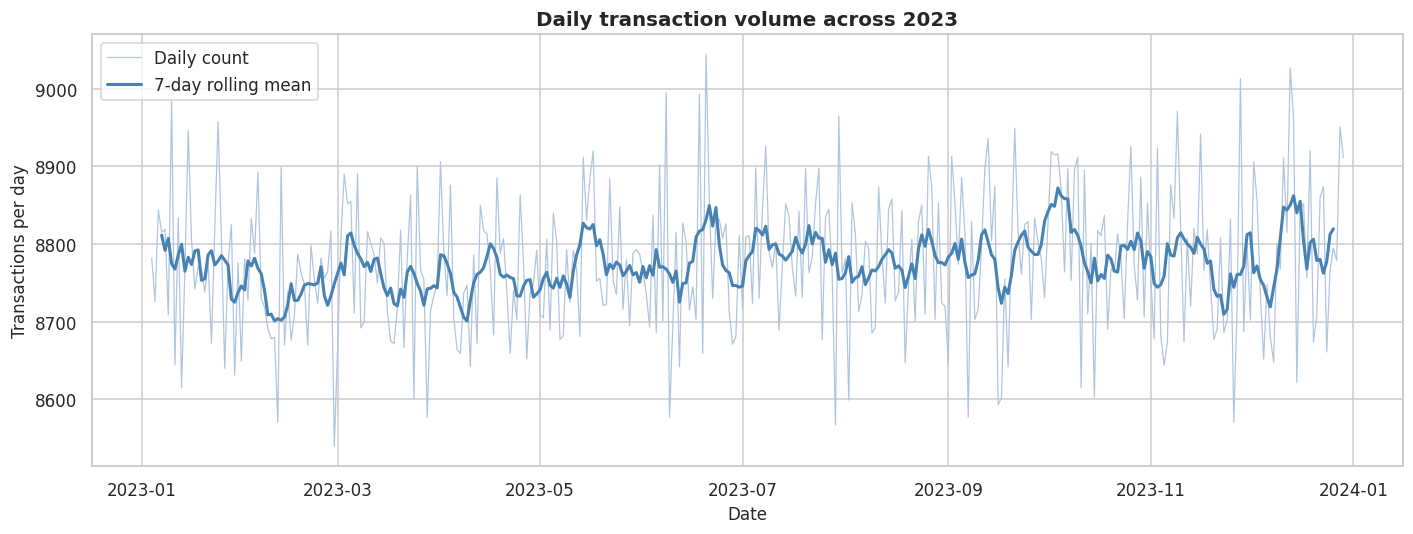

In [27]:
t0 = time.time()
daily = tx.groupby(tx["date"].dt.normalize()).agg(
    n_transactions=("amount", "size"),
    total_amount=("amount", "sum"),
).reset_index()
daily["rolling_7d"] = daily["n_transactions"].rolling(7, center=True).mean()
log_step("daily aggregation (groupby date, 3.16M rows)", t0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily["date"], daily["n_transactions"], color="lightsteelblue", linewidth=0.8, label="Daily count")
ax.plot(daily["date"], daily["rolling_7d"], color="steelblue", linewidth=2, label="7-day rolling mean")
ax.set_title("Daily transaction volume across 2023")
ax.set_ylabel("Transactions per day")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()

print(f"Daily transaction count: mean {daily['n_transactions'].mean():,.0f}, "
      f"min {daily['n_transactions'].min():,}, max {daily['n_transactions'].max():,}")
print(f"Coefficient of variation: {daily['n_transactions'].std()/daily['n_transactions'].mean()*100:.1f}%")

Weekend transactions: 28.3% of all activity (2/7 = 28.6% would be the no-effect baseline)


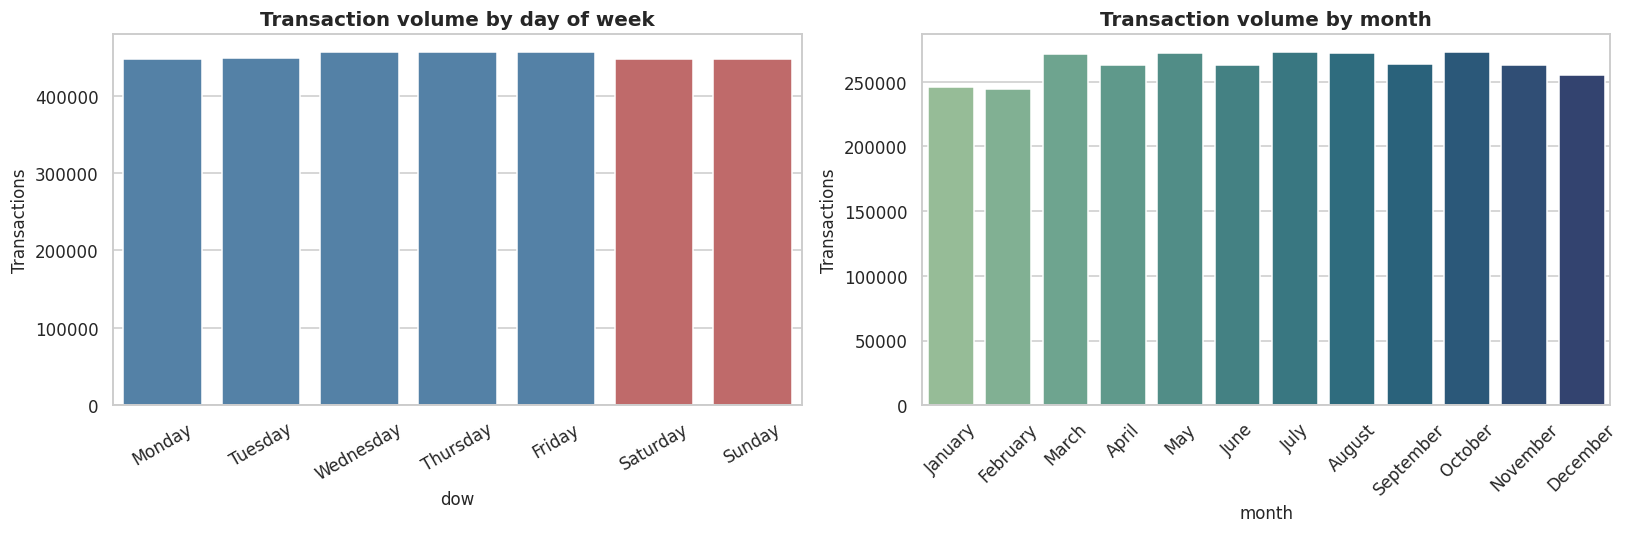

In [28]:
tx["dow"] = tx["date"].dt.day_name()
tx["month"] = tx["date"].dt.month_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
month_order = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

dow_counts = tx.groupby("dow").size().reindex(dow_order)
colors = ["steelblue"]*5 + ["indianred"]*2
sns.barplot(x=dow_counts.index, y=dow_counts.values, hue=dow_counts.index,
            palette=colors, legend=False, ax=axes[0])
axes[0].set_title("Transaction volume by day of week")
axes[0].set_ylabel("Transactions")
axes[0].tick_params(axis="x", rotation=30)

month_counts = tx.groupby("month").size().reindex(month_order)
sns.barplot(x=month_counts.index, y=month_counts.values, hue=month_counts.index, palette="crest",
            legend=False, ax=axes[1])
axes[1].set_title("Transaction volume by month")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
weekend_share = tx["dow"].isin(["Saturday", "Sunday"]).mean() * 100
print(f"Weekend transactions: {weekend_share:.1f}% of all activity "
      f"(2/7 = 28.6% would be the no-effect baseline)")

## 10. Correlation Structure

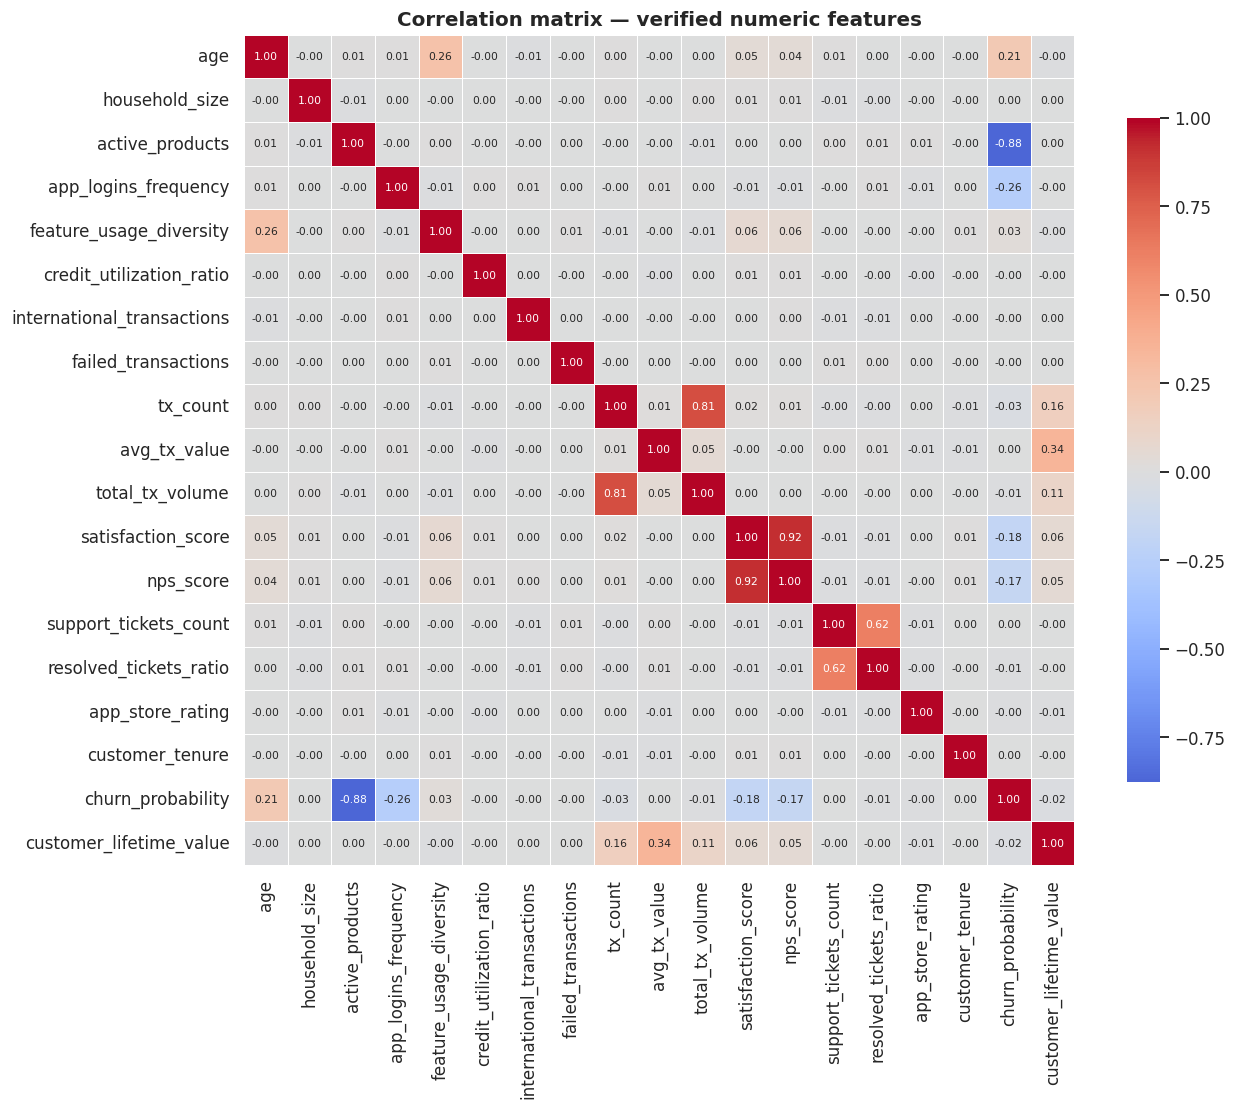

In [29]:
numeric_cols = [
    "age", "household_size", "active_products", "app_logins_frequency", "feature_usage_diversity",
    "credit_utilization_ratio", "international_transactions", "failed_transactions",
    "tx_count", "avg_tx_value", "total_tx_volume", "satisfaction_score", "nps_score",
    "support_tickets_count", "resolved_tickets_ratio", "app_store_rating",
    "customer_tenure", "churn_probability", "customer_lifetime_value",
]
corr = cust[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7},
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — verified numeric features")
plt.tight_layout()

In [30]:
target_related = corr[["churn_probability", "customer_lifetime_value", "satisfaction_score"]] \
                    .drop(["churn_probability", "customer_lifetime_value", "satisfaction_score"])
target_related.sort_values("churn_probability", key=abs, ascending=False)

,churn_probability,customer_lifetime_value,satisfaction_score
active_products,-0.875972,0.001241,0.001023
app_logins_frequency,-0.256466,-0.001776,-0.011268
age,0.211312,-0.004568,0.046510
nps_score,-0.167593,0.051148,0.916708
feature_usage_diversity,0.028740,-0.004867,0.063322
tx_count,-0.028062,0.163954,0.017435
total_tx_volume,-0.013028,0.107269,0.002335
resolved_tickets_ratio,-0.005885,-0.001635,-0.005543
app_store_rating,-0.004775,-0.005367,0.000073
failed_transactions,-0.003671,0.000365,0.000451


## 11. Signals for the Four Workstreams

A quick, targeted look at each teammate's outcome variable, using only the ledger-verified
features from Section 3.4.

**Clifton — inactivity & retention.** Proxy for future inactivity: recent activity level by customer segment.

                  tx_count  satisfaction_score  support_tickets_count
customer_segment                                                     
inactive             59.33                4.17                   1.00
occasional           63.51                4.16                   0.99
regular              63.02                4.16                   0.99
power                86.84                4.16                   1.02


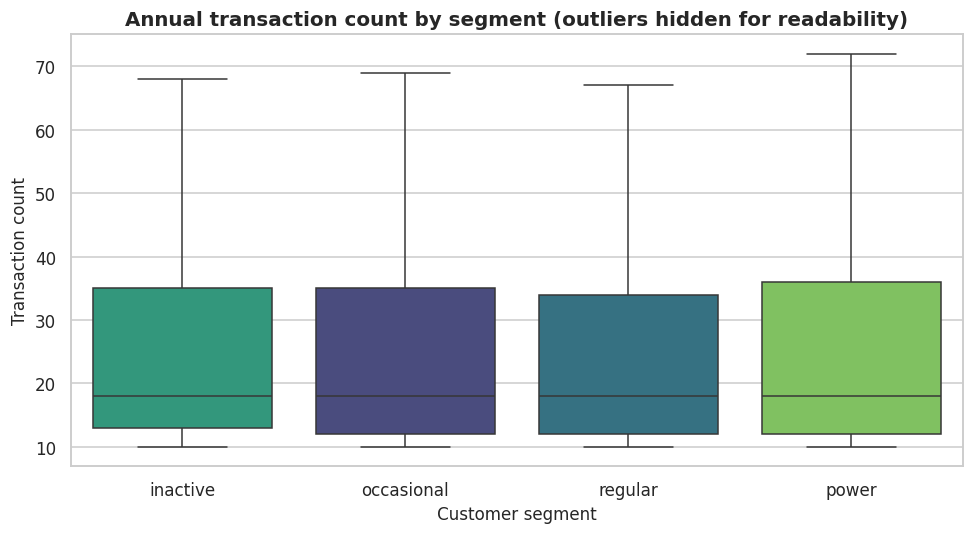

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x="customer_segment", y="tx_count", data=cust, order=SEGMENT_ORDER,
            hue="customer_segment", palette="viridis", legend=False, showfliers=False, ax=ax)
ax.set_title("Annual transaction count by segment (outliers hidden for readability)")
ax.set_xlabel("Customer segment")
ax.set_ylabel("Transaction count")
plt.tight_layout()

print(cust.groupby("customer_segment")[["tx_count", "satisfaction_score", "support_tickets_count"]]
      .mean().reindex(SEGMENT_ORDER).round(2))

**Evan — future customer value.** Are today's high-value customers the same as tomorrow's high-growth-potential ones?

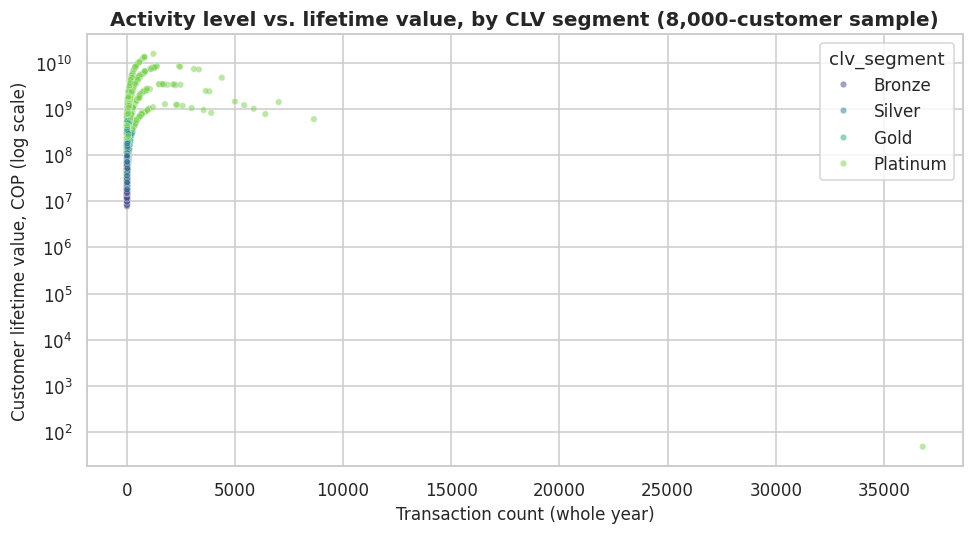

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = cust.sample(8000, random_state=42)
sns.scatterplot(data=sample, x="tx_count", y="customer_lifetime_value", hue="clv_segment",
                 hue_order=CLV_ORDER, palette="viridis", alpha=0.5, s=18, ax=ax)
ax.set_yscale("log")
ax.set_title("Activity level vs. lifetime value, by CLV segment (8,000-customer sample)")
ax.set_xlabel("Transaction count (whole year)")
ax.set_ylabel("Customer lifetime value, COP (log scale)")
plt.tight_layout()

**Yi Ting — satisfaction & experience.** Already covered in Section 7 (complaint topics vs. satisfaction). Adding failed transactions as a candidate operational-friction driver.

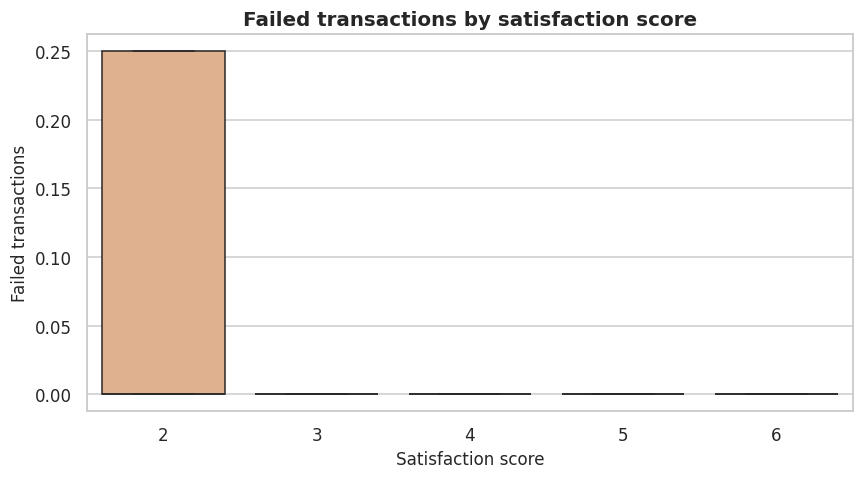

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(x="satisfaction_score", y="failed_transactions", data=cust,
            hue="satisfaction_score", palette="flare", legend=False, showfliers=False, ax=ax)
ax.set_title("Failed transactions by satisfaction score")
ax.set_xlabel("Satisfaction score")
ax.set_ylabel("Failed transactions")
plt.tight_layout()

**Kang Bin — transaction demand classification.** Daily series already shown in Section 9; checking whether an active-customer count adds information beyond raw transaction counts.

Correlation(active customers, transaction count) = 0.726


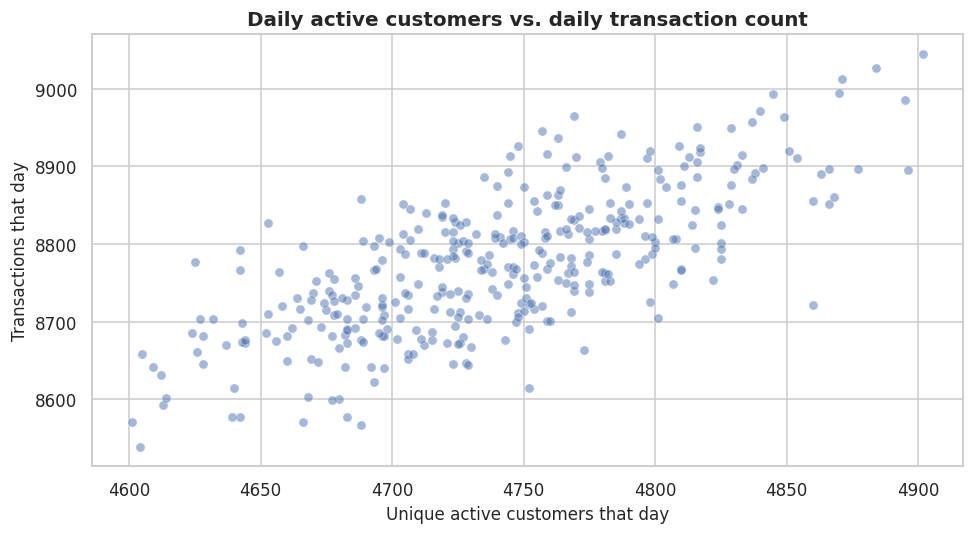

In [34]:
daily_active = tx.groupby(tx["date"].dt.normalize())["customer_id"].nunique().rename("active_customers")
demand = daily.set_index("date").join(daily_active)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=demand, x="active_customers", y="n_transactions", alpha=0.5, ax=ax)
ax.set_title("Daily active customers vs. daily transaction count")
ax.set_xlabel("Unique active customers that day")
ax.set_ylabel("Transactions that day")
plt.tight_layout()

print(f"Correlation(active customers, transaction count) = "
      f"{demand['active_customers'].corr(demand['n_transactions']):.3f}")

## 12. Processing Time & a First Scalability Probe

The proposal calls for recording ingestion, cleaning, join, and aggregation time, and for testing
runtime growth at 25/50/75/100% of the data. This notebook runs single-threaded on one machine, so
these numbers are a **baseline reference point**, not the cloud benchmark itself — the full
pipeline will repeat this methodology on the Spark/Databricks cluster at much larger scale.

In [35]:
log_df = pd.DataFrame(processing_log)
log_df

,step,seconds
0,load customer_data.csv,0.678
1,load transactions_data.csv,3.883
2,uniqueness + referential integrity check,1.297
3,date coverage check,0.120
4,groupby customer_id over 3.16M rows,0.143
5,"daily aggregation (groupby date, 3.16M rows)",0.176


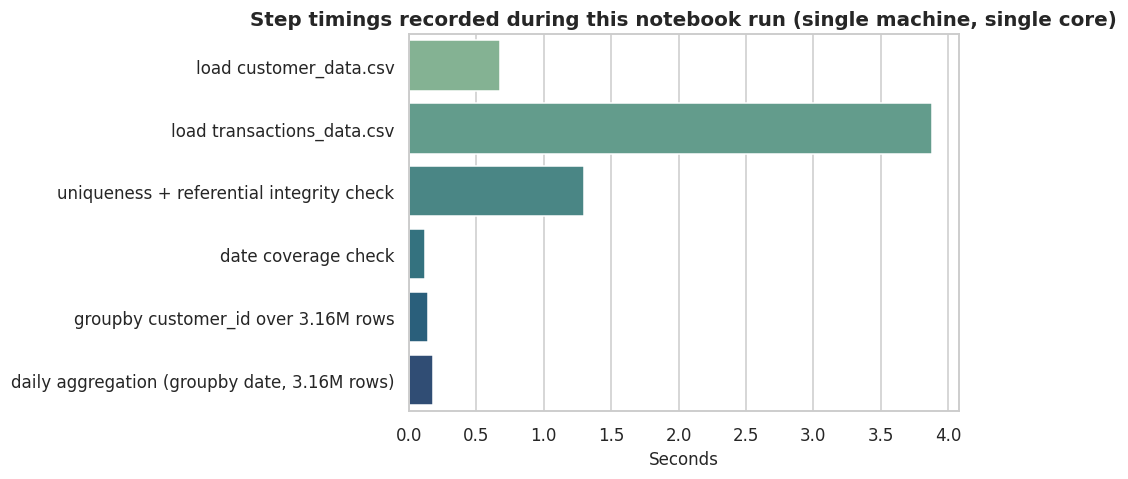

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x="seconds", y="step", data=log_df, hue="step", palette="crest", legend=False, ax=ax)
ax.set_title("Step timings recorded during this notebook run (single machine, single core)")
ax.set_xlabel("Seconds")
ax.set_ylabel("")
plt.tight_layout()

In [37]:
# Lightweight scaling probe: how does load + aggregation time grow with row count?
fractions = [0.25, 0.50, 0.75, 1.00]
total_rows = sum(1 for _ in open(f"{DATA_DIR}/transactions_data.csv")) - 1
scaling_results = []

for frac in fractions:
    n = int(total_rows * frac)
    t0 = time.time()
    sample_tx = pd.read_csv(f"{DATA_DIR}/transactions_data.csv", nrows=n, parse_dates=["date"])
    _ = sample_tx.groupby(sample_tx["date"].dt.normalize())["amount"].agg(["size", "sum"])
    elapsed = time.time() - t0
    scaling_results.append({"fraction": f"{int(frac*100)}%", "rows": n, "seconds": round(elapsed, 2)})

scaling_df = pd.DataFrame(scaling_results)
scaling_df

,fraction,rows,seconds
0,25%,789789,0.55
1,50%,1579578,1.07
2,75%,2369367,1.87
3,100%,3159157,2.50


Runtime grows roughly linearly with row count on a single machine at this scale, as
expected for a groupby/aggregate workload -- the cloud benchmark should confirm whether
the distributed pipeline holds the same (or better) scaling once ingestion, joins, and
feature engineering are all included, per the proposal's Section on Scalability.


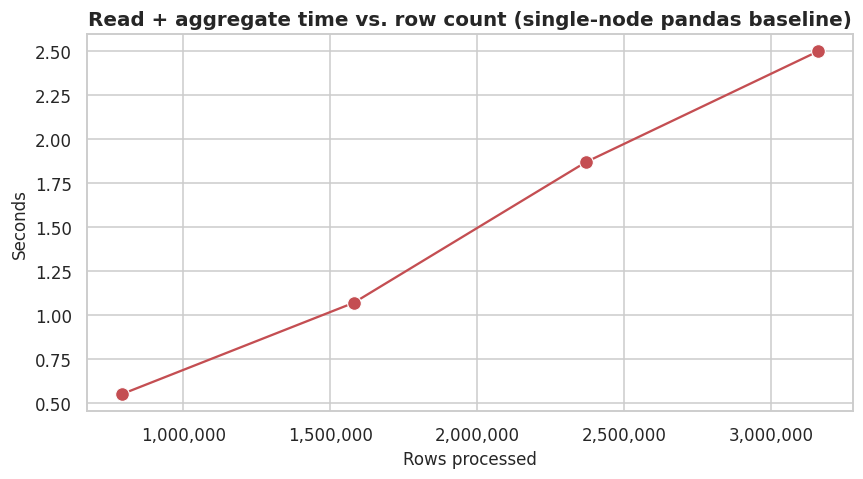

In [38]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=scaling_df, x="rows", y="seconds", marker="o", markersize=9,
             color=sns.color_palette("deep")[3], ax=ax)
ax.set_title("Read + aggregate time vs. row count (single-node pandas baseline)")
ax.set_xlabel("Rows processed")
ax.set_ylabel("Seconds")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
plt.tight_layout()
print("Runtime grows roughly linearly with row count on a single machine at this scale, as")
print("expected for a groupby/aggregate workload -- the cloud benchmark should confirm whether")
print("the distributed pipeline holds the same (or better) scaling once ingestion, joins, and")
print("feature engineering are all included, per the proposal's Section on Scalability.")

## 13. Summary of Findings

**Data quality is strong, with one important caveat.**
- `customer_id` is a clean primary key; the join between the two tables is complete and lossless
  (every customer has transactions, every transaction belongs to a known customer).
- All 360 calendar days in the coverage window have transaction activity — no ingestion gaps.
- Only 3 of 54 customer-level columns have missing values, and all three are *structurally*
  missing (no credit card → no utilization ratio; no complaint filed → no complaint topic; no
  request submitted → no feature request), not random gaps needing imputation.
- **`tx_count`, `avg_tx_value`, `total_tx_volume`, `first_tx`, and `last_tx` are 100% verified**
  against the raw ledger and safe to use directly. A second, similarly-named group of columns
  (`average_transaction_value`, `total_transaction_volume`, `weekend_transaction_ratio`,
  `last_transaction_date`, and friends) does **not** reconcile with the ledger — correlations near
  zero — and should be excluded from feature engineering or recomputed from `transactions_data.csv`
  directly. This is worth raising with all four workstream owners before modeling starts, since it
  affects shared preprocessing.
- 102 exactly-duplicated transaction rows (0.003%) exist and should be resolved (drop vs. keep)
  with an explicit, documented rule.

**Patterns relevant to each workstream**
- *Inactivity (Clifton):* `customer_segment` cleanly separates activity level (`inactive` customers
  transact far less than `power` users), and support tickets/satisfaction differ by segment too —
  both are plausible predictors of near-term inactivity.
- *Future value (Evan):* activity level and lifetime value are related but not interchangeable —
  some low-activity customers still sit in high CLV segments, consistent with the proposal's
  hypothesis that "high historical value" and "high growth potential" may be distinct groups.
- *Satisfaction (Yi Ting):* customers with a recorded complaint have measurably lower mean
  satisfaction than those without one, and failed transactions trend higher among lower
  satisfaction scores — an early signal that operational friction matters, to be tested formally
  rather than assumed.
- *Demand classification (Kang Bin):* daily transaction volume is stable with a clear weekday/
  weekend split and a strong same-day relationship between active customers and transaction count
  — both good candidate features for `next_day_demand_class`.

**Caveats to carry forward**
- Coverage is a single calendar year — chronological/walk-forward validation is required, per the
  proposal, before claiming any seasonal pattern generalizes.
- `customer_lifetime_value`, transaction amounts, and CLV are heavily right-skewed (log-scale plots
  were needed throughout) — log transforms or robust scalers will likely be necessary for the
  regression/classification workstreams.
- This notebook profiles pandas performance on a single machine as a baseline only; the cloud
  benchmark (Section 12 of the proposal) still needs to be run on the actual Spark/Databricks
  cluster at full scale.

**Next step:** shared preprocessing (deduplication rule, Set-B column exclusion, train/test cutoff
dates) can now be finalized, after which each teammate branches into their own feature-engineering
and modeling notebook.